# Heatwave Risk — Report Visualisations
**Kazakhstan CLIMAAX adaptation**

Loads cached outputs from `heatwave_risk_projection_kz` and
`heatwave_hazard_xclim_kz` notebooks.  All figures saved to `Report_figures/`.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import rasterstats
import rasterio
from rasterio.transform import from_origin
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cartopy.crs as ccrs
import plotly.graph_objects as go

HAZARD_DATA    = Path('Heatwave_risk_projection_KZ/data')
HAZARD_RESULTS = Path('Heatwave_risk_projection_KZ/results')
REPORT_DIR     = Path('Report_figures')
REPORT_DIR.mkdir(exist_ok=True)

SHAPEFILE_PATH = Path(
    r"C:\Users\dauzo\Models\crabook-kazakhstan\crabook"
    r"\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp"
)  
OBLAST_FIELD = 'oblast_en'

MODEL      = 'gfdl-esm4'
ASTANA_LAT = 51.18
ASTANA_LON = 71.45

HIST_SLICE = slice('1985', '2014')
NEAR_SLICE = slice('2015', '2044')
FAR_SLICE  = slice('2045', '2074')

PANELS = [
    ('SSP1-2.6', NEAR_SLICE, '2015-2044'),
    ('SSP1-2.6', FAR_SLICE,  '2045-2074'),
    ('SSP3-7.0', NEAR_SLICE, '2015-2044'),
    ('SSP3-7.0', FAR_SLICE,  '2045-2074'),
]

FIG_KW = dict(dpi=150, bbox_inches='tight')
PC_CRS = ccrs.PlateCarree()

print('Report output:', REPORT_DIR.resolve())

Report output: C:\Users\dauzo\Models\crabook-kazakhstan\crabook\notebooks\workflows\HEATWAVES\01_Urban_heatwaves\Report_figures


In [ ]:
kaz_gdf     = gpd.read_file(SHAPEFILE_PATH)
gdf_oblasts = kaz_gdf.dissolve(by=OBLAST_FIELD).reset_index().to_crs('EPSG:4326')
bbox        = gdf_oblasts.total_bounds   # [minx, miny, maxx, maxy]

def _load_hwi(sc):
    p = HAZARD_DATA / f'{MODEL}_{sc}_hwi_kz.nc'
    if not p.exists():
        raise FileNotFoundError(f'Cache missing: {p}')
    return xr.open_dataarray(p)

hwi_hist = _load_hwi('historical')
hwi_126  = _load_hwi('ssp126')
hwi_370  = _load_hwi('ssp370')

risk_files = sorted(HAZARD_RESULTS.glob('risk_*.gpkg'))
if len(risk_files) != 4:
    raise FileNotFoundError(
        f'Expected 4 risk_*.gpkg in {HAZARD_RESULTS}; found {len(risk_files)}.\n'
        f'Files present: {[f.name for f in risk_files]}'
    )
print('Risk GeoPackages:', [f.name for f in risk_files])
risk_gdfs = {
    (sc, per): gpd.read_file(f)
    for (sc, _, per), f in zip(PANELS, risk_files)
}
gdf_pop = gpd.read_file(HAZARD_RESULTS / 'population_classified_oblasts.gpkg')
print('[OK] Inputs loaded.')

Risk GeoPackages: ['risk_SSP12_6_2015_2044.gpkg', 'risk_SSP12_6_2045_2074.gpkg', 'risk_SSP37_0_2015_2044.gpkg', 'risk_SSP37_0_2045_2074.gpkg']
[OK] Inputs loaded.


In [ ]:
def _pm(da, sl):
    return da.sel(time=sl).mean(dim='time', skipna=True)

hw_hist     = _pm(hwi_hist, HIST_SLICE)
hw_126_near = _pm(hwi_126,  NEAR_SLICE)
hw_126_far  = _pm(hwi_126,  FAR_SLICE)
hw_370_near = _pm(hwi_370,  NEAR_SLICE)
hw_370_far  = _pm(hwi_370,  FAR_SLICE)

_futures = [hw_126_near, hw_126_far, hw_370_near, hw_370_far]

hist_safe = hw_hist.where(hw_hist > 0)
RC_MAPS   = {
    (sc, per): ((fut - hw_hist) / hist_safe) * 100
    for (sc, _, per), fut in zip(PANELS, _futures)
}

def _zonal(gdf_in, da, col):
    lats = da.lat.values;  lons = da.lon.values
    data = da.values.astype(np.float32)
    rx, ry = float(lons[1]-lons[0]), float(lats[1]-lats[0])
    tf = from_origin(
        float(lons[0]) - rx/2,
        float(lats[-1]) + abs(ry)/2,
        abs(rx), abs(ry),
    )
    if lats[0] < lats[-1]:
        data = data[::-1, :]
    tmp = REPORT_DIR / '_tmp.tif'
    with rasterio.open(
        tmp, 'w', driver='GTiff',
        height=data.shape[0], width=data.shape[1],
        count=1, dtype='float32', crs='EPSG:4326',
        transform=tf, nodata=np.nan,
    ) as dst:
        dst.write(data, 1)
    stats = rasterstats.zonal_stats(
        gdf_in, str(tmp),
        stats='mean', all_touched=True, nodata=np.nan, boundless=True,
    )
    gdf_out = gdf_in.copy()
    gdf_out[col] = [s['mean'] if s['mean'] is not None else np.nan for s in stats]
    tmp.unlink(missing_ok=True)
    return gdf_out

rc_gdfs = {}
for sc, _, per in PANELS:
    rc_gdfs[(sc, per)] = _zonal(gdf_oblasts, RC_MAPS[(sc, per)], 'rc_mean')
    print(f'  Zonal stats done: {sc} {per}')

all_rc  = np.concatenate([g['rc_mean'].dropna().values for g in rc_gdfs.values()])
RC_MIN  = float(np.nanmin(all_rc))
RC_P95  = float(np.nanpercentile(all_rc, 95))   # cap colourmap at 95th percentile
print(f'Relative change range: {RC_MIN:.0f}% - {float(np.nanmax(all_rc)):.0f}%  '
      f'(95th pct cap: {RC_P95:.0f}%)')

def _pt(da):
    return da.sel(lat=ASTANA_LAT, lon=ASTANA_LON, method='nearest').values.astype(float)

ts_hist     = _pt(hwi_hist)
ts_126      = _pt(hwi_126)
ts_370      = _pt(hwi_370)
yrs_hist    = [int(str(t)[:4]) for t in hwi_hist.time.values]
yrs_fut     = [int(str(t)[:4]) for t in hwi_126.time.values]
yrs_full    = yrs_hist + yrs_fut
ts_full_126 = np.concatenate([ts_hist, ts_126])
ts_full_370 = np.concatenate([ts_hist, ts_370])

def _roll(arr, w=20):
    return pd.Series(arr).rolling(w, center=True, min_periods=w//2).mean().values

def _surv(arr):
    s = np.sort(arr[np.isfinite(arr)])[::-1]
    return s, np.arange(1, len(s)+1) / (len(s)+1)

def _cartopy_map(ax, pad=0.5):
    ax.set_extent(
        [bbox[0]-pad, bbox[2]+pad, bbox[1]-pad, bbox[3]+pad], crs=PC_CRS
    )
    gdf_oblasts.plot(ax=ax, facecolor='none', edgecolor='0.35',
                     linewidth=0.4, transform=PC_CRS)
    gl = ax.gridlines(draw_labels=True, linewidth=0.2, alpha=0.35)
    gl.top_labels = False;  gl.right_labels = False
    gl.xlabel_style = {'size': 6};  gl.ylabel_style = {'size': 6}

print('[OK] Derived datasets and helpers ready.')

  Zonal stats done: SSP1-2.6 2015-2044
  Zonal stats done: SSP1-2.6 2045-2074
  Zonal stats done: SSP3-7.0 2015-2044
  Zonal stats done: SSP3-7.0 2045-2074
Relative change range: 60% - 1979%  (95th pct cap: 1093%)
[OK] Derived datasets and helpers ready.


## Historical Heatwave Intensity

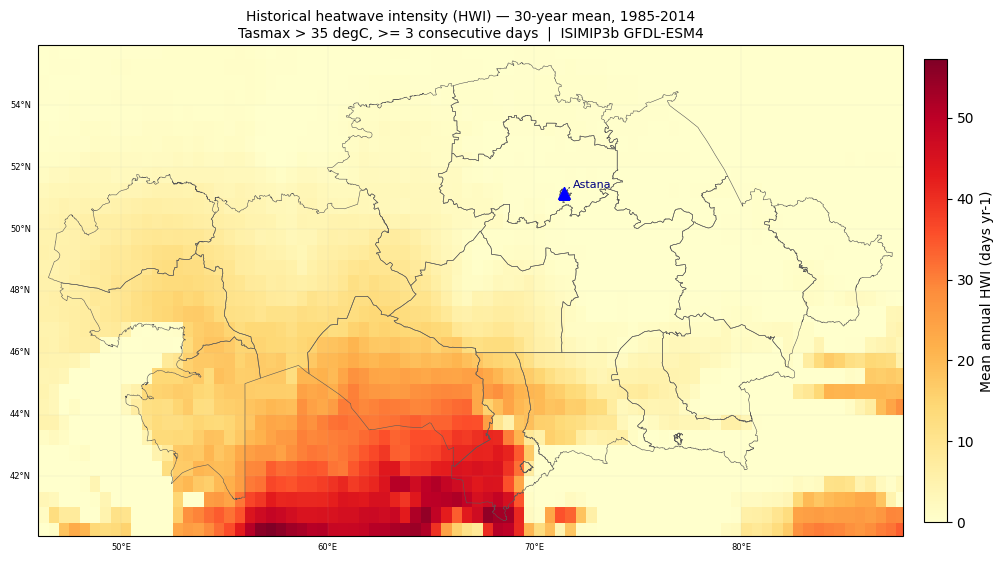

Saved -> Report_figures\fig01_historical_hwi.png


In [4]:
fig, ax = plt.subplots(figsize=(11, 6), subplot_kw={'projection': PC_CRS})
im = ax.pcolormesh(
    hw_hist.lon.values, hw_hist.lat.values, hw_hist.values,
    cmap='YlOrRd', vmin=0, transform=PC_CRS,
)
_cartopy_map(ax)
ax.plot(ASTANA_LON, ASTANA_LAT, 'b^', ms=9, transform=PC_CRS, zorder=5)
ax.text(ASTANA_LON+0.4, ASTANA_LAT+0.15, 'Astana',
        transform=PC_CRS, fontsize=8, color='navy')
plt.colorbar(im, ax=ax, shrink=0.82, pad=0.02, label='Mean annual HWI (days yr-1)')
ax.set_title(
    f'Historical heatwave intensity (HWI) — 30-year mean, 1985-2014\n'
    f'Tasmax > 35 degC, >= 3 consecutive days  |  ISIMIP3b {MODEL.upper()}',
    fontsize=10,
)
plt.tight_layout()
out = REPORT_DIR / 'fig01_historical_hwi.png'
plt.savefig(out, **FIG_KW);  plt.show()
print(f'Saved -> {out}')

## Projected HWI — Four-Scenario Spatial Overview

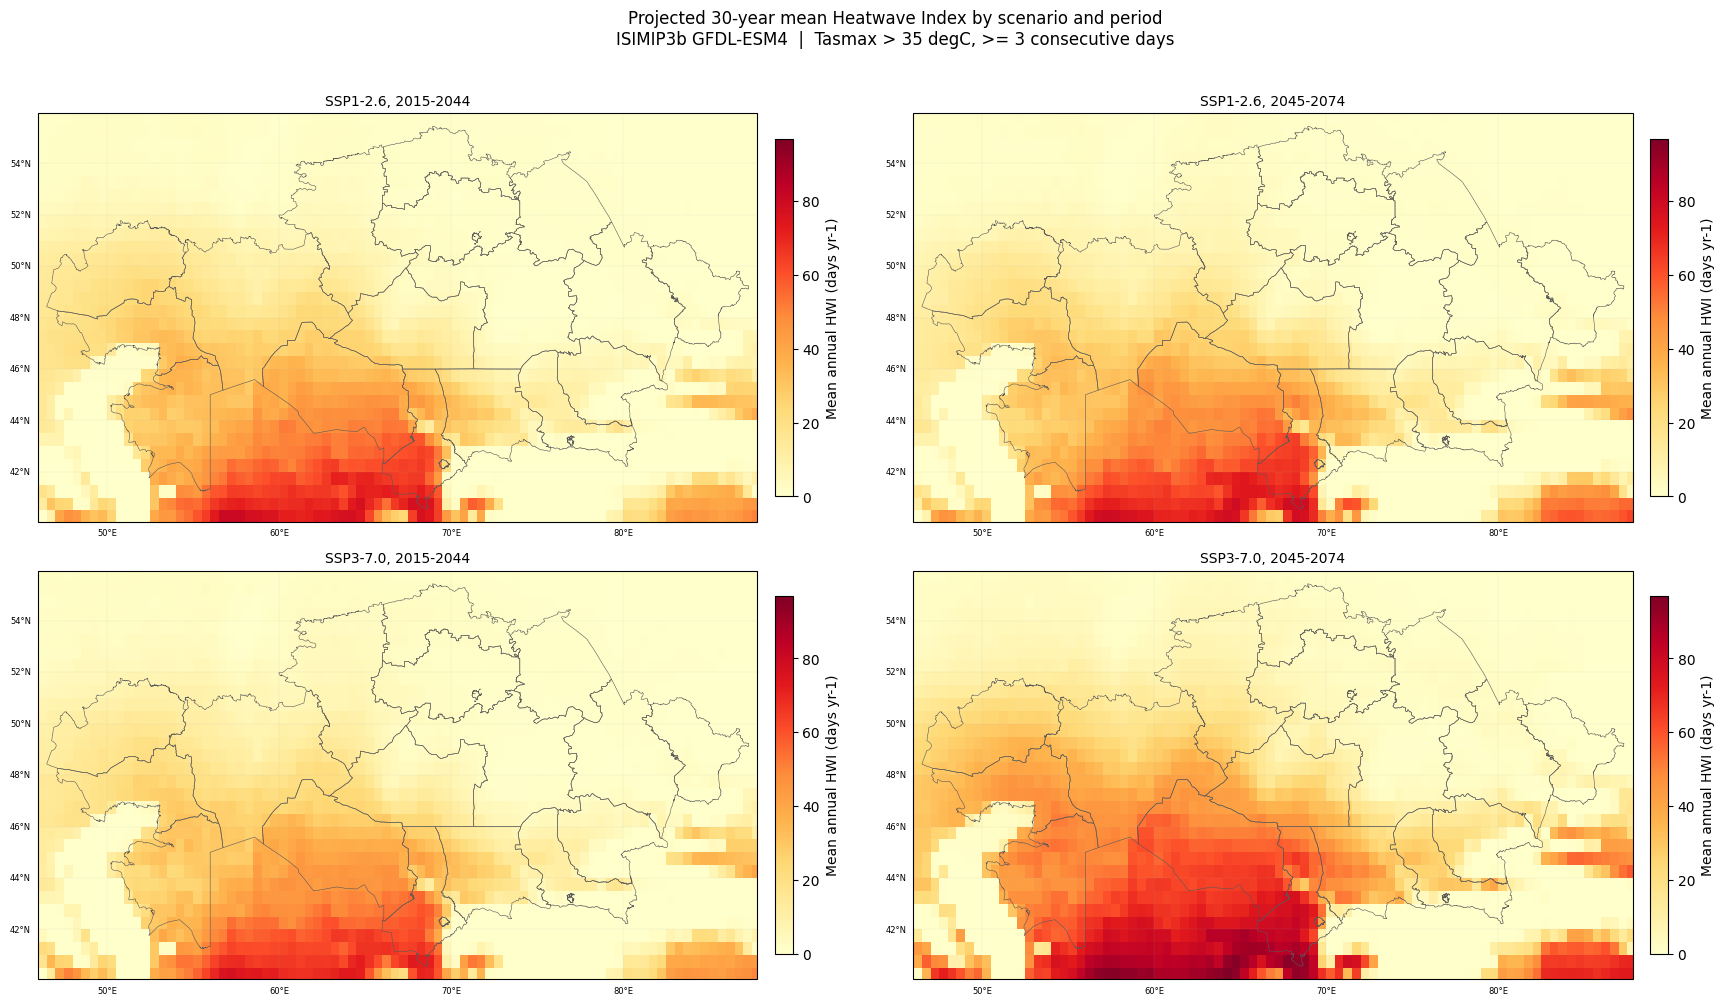

Saved -> Report_figures\fig02_projected_hwi_4panel.png


In [5]:
_proj_maps = [hw_126_near, hw_126_far, hw_370_near, hw_370_far]
_vmax_proj = max(float(m.max()) for m in _proj_maps)

fig, axes = plt.subplots(2, 2, figsize=(18, 10),
                         subplot_kw={'projection': PC_CRS})
for ax, da, (sc, _, per) in zip(axes.flat, _proj_maps, PANELS):
    im = ax.pcolormesh(
        da.lon.values, da.lat.values, da.values,
        cmap='YlOrRd', vmin=0, vmax=_vmax_proj, transform=PC_CRS,
    )
    _cartopy_map(ax)
    plt.colorbar(im, ax=ax, shrink=0.78, pad=0.02,
                 label='Mean annual HWI (days yr-1)')
    ax.set_title(f'{sc}, {per}', fontsize=10)

plt.suptitle(
    f'Projected 30-year mean Heatwave Index by scenario and period\n'
    f'ISIMIP3b {MODEL.upper()}  |  Tasmax > 35 degC, >= 3 consecutive days',
    fontsize=12, y=1.01,
)
plt.tight_layout()
out = REPORT_DIR / 'fig02_projected_hwi_4panel.png'
plt.savefig(out, **FIG_KW);  plt.show()
print(f'Saved -> {out}')

## Relative Change in Heatwave Occurrence by Oblast

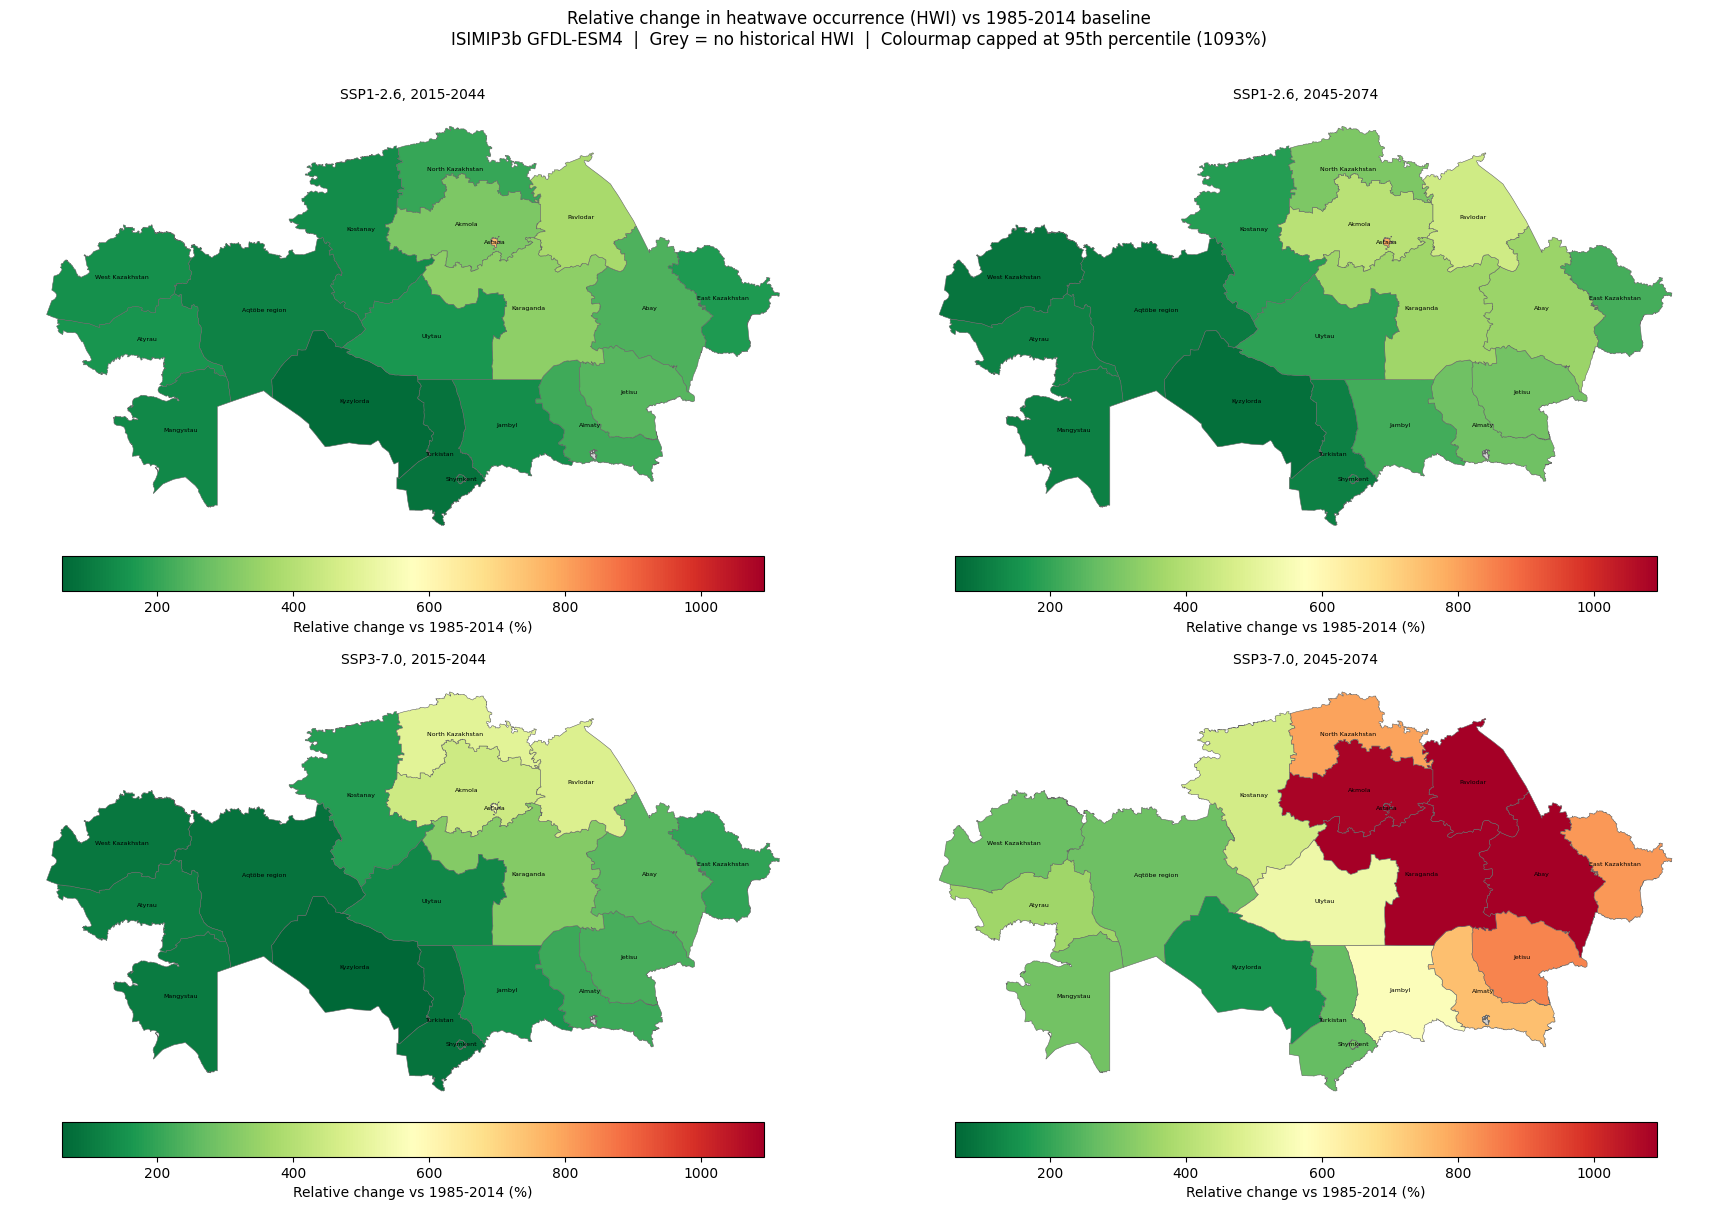

Saved -> Report_figures\fig03_relative_change_4panel.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, (sc, _, per) in zip(axes.flat, PANELS):
    g = rc_gdfs[(sc, per)]
    g.plot(
        column='rc_mean', ax=ax, cmap='RdYlGn_r',
        vmin=max(0, RC_MIN), vmax=RC_P95,
        edgecolor='0.4', linewidth=0.4, legend=True,
        missing_kwds={'color': 'lightgrey', 'label': 'No baseline HWI'},
        legend_kwds={
            'label': 'Relative change vs 1985-2014 (%)',
            'orientation': 'horizontal', 'shrink': 0.8, 'pad': 0.02,
        },
    )
    for _, row in g.dropna(subset=['rc_mean']).iterrows():
        cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
        ax.text(cx, cy,
                str(row[OBLAST_FIELD]).replace(' Region', ''),
                fontsize=4.5, ha='center', va='center')
    ax.set_title(f'{sc}, {per}', fontsize=10)
    ax.axis('off')

plt.suptitle(
    f'Relative change in heatwave occurrence (HWI) vs 1985-2014 baseline\n'
    f'ISIMIP3b {MODEL.upper()}  |  Grey = no historical HWI  '
    f'|  Colourmap capped at 95th percentile ({RC_P95:.0f}%)',
    fontsize=12, y=1.01,
)
plt.tight_layout()
out = REPORT_DIR / 'fig03_relative_change_4panel.png'
plt.savefig(out, **FIG_KW);  plt.show()
print(f'Saved -> {out}')

## Scenario Comparison — Annual HWI Time Series (Astana)

In [7]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=yrs_full, y=ts_full_126.tolist(),
    name='SSP1-2.6', marker_color='steelblue', opacity=0.45,
))
fig.add_trace(go.Bar(
    x=yrs_full, y=ts_full_370.tolist(),
    name='SSP3-7.0', marker_color='firebrick', opacity=0.45,
))
fig.add_trace(go.Scatter(
    x=yrs_full, y=_roll(ts_full_126).tolist(),
    name='SSP1-2.6 (20-yr mean)',
    line={'color': 'steelblue', 'width': 2.5},
))
fig.add_trace(go.Scatter(
    x=yrs_full, y=_roll(ts_full_370).tolist(),
    name='SSP3-7.0 (20-yr mean)',
    line={'color': 'firebrick', 'width': 2.5},
))
fig.add_vrect(
    x0=1985, x1=2014,
    fillcolor='lightgrey', opacity=0.25, line_width=0,
    annotation_text='Baseline 1985-2014',
    annotation_position='top left',
    annotation_font_size=9,
)
fig.update_layout(
    title={
        'text': (
            f'Annual Heatwave Index (HWI) — Astana '
            f'(lat {ASTANA_LAT}N, lon {ASTANA_LON}E)<br>'
            f'Tasmax > 35 degC, >= 3 consecutive days  |  '
            f'ISIMIP3b {MODEL.upper()}'
        ),
        'x': 0.5, 'xanchor': 'center',
    },
    xaxis_title='Year',
    yaxis_title='HWI (days yr-1)',
    barmode='overlay',
    legend={'x': 0, 'y': 1, 'orientation': 'h'},
    width=1100, height=480,
)
fig.write_html(str(REPORT_DIR / 'fig04_timeseries_astana.html'))
fig.show()
print('Saved -> fig04_timeseries_astana.html')

Saved -> fig04_timeseries_astana.html


## Exceedance Probability Curves (Astana)

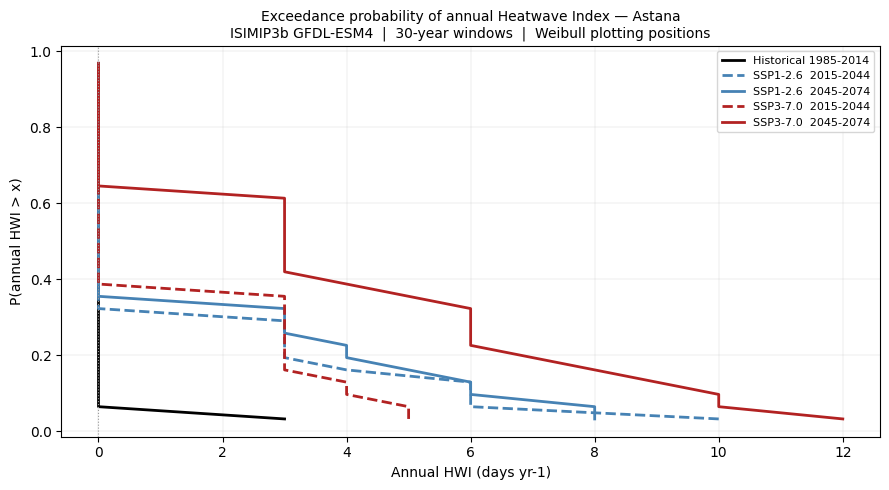

Saved -> Report_figures\fig05_exceedance_astana.png


In [8]:
_surv_series = [
    ('Historical 1985-2014',  _pt(hwi_hist.sel(time=HIST_SLICE)), 'black',     '-'),
    ('SSP1-2.6  2015-2044',   _pt(hwi_126.sel(time=NEAR_SLICE)),  'steelblue', '--'),
    ('SSP1-2.6  2045-2074',   _pt(hwi_126.sel(time=FAR_SLICE)),   'steelblue', '-'),
    ('SSP3-7.0  2015-2044',   _pt(hwi_370.sel(time=NEAR_SLICE)),  'firebrick', '--'),
    ('SSP3-7.0  2045-2074',   _pt(hwi_370.sel(time=FAR_SLICE)),   'firebrick', '-'),
]

fig, ax = plt.subplots(figsize=(9, 5))
for label, arr, col, ls in _surv_series:
    vals, probs = _surv(arr)
    ax.plot(vals, probs, color=col, ls=ls, lw=2, label=label)

ax.axvline(0, color='0.6', lw=0.8, ls=':')
ax.set_xlabel('Annual HWI (days yr-1)', fontsize=10)
ax.set_ylabel('P(annual HWI > x)', fontsize=10)
ax.set_title(
    f'Exceedance probability of annual Heatwave Index — Astana\n'
    f'ISIMIP3b {MODEL.upper()}  |  30-year windows  |  Weibull plotting positions',
    fontsize=10,
)
ax.legend(fontsize=8)
ax.grid(linewidth=0.3, alpha=0.5)
plt.tight_layout()
out = REPORT_DIR / 'fig05_exceedance_astana.png'
plt.savefig(out, **FIG_KW);  plt.show()
print(f'Saved -> {out}')

## Oblast Hazard Ranking — SSP3-7.0, 2045-2074

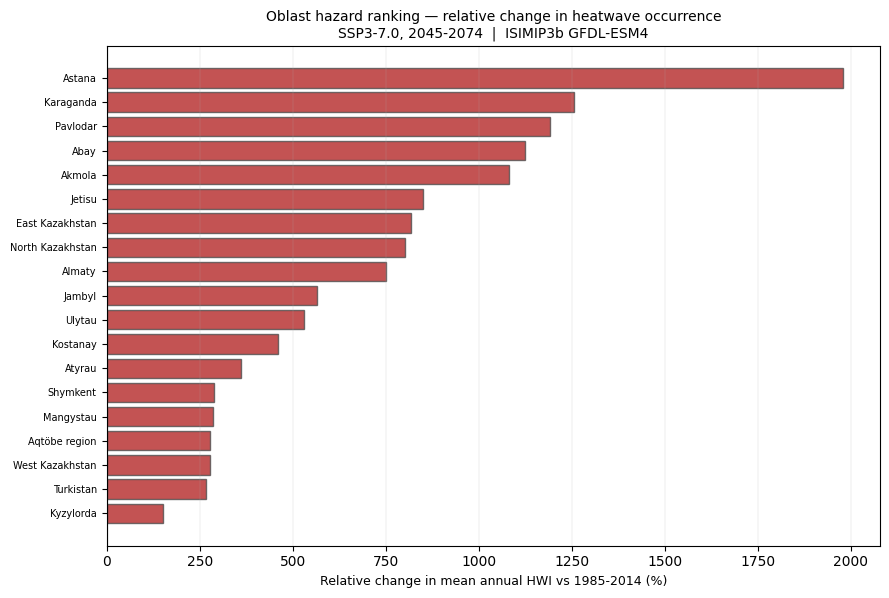

Saved -> Report_figures\fig06_oblast_hazard_ranking.png


In [9]:
g_rank = (rc_gdfs[('SSP3-7.0', '2045-2074')]
          .dropna(subset=['rc_mean'])
          .sort_values('rc_mean', ascending=True))
_labels = g_rank[OBLAST_FIELD].str.replace(' Region', '', regex=False)

fig, ax = plt.subplots(figsize=(9, max(5, len(g_rank) * 0.32)))
ax.barh(_labels, g_rank['rc_mean'],
        color='firebrick', alpha=0.78, edgecolor='0.3')
ax.axvline(0, color='0.4', lw=0.8)
ax.set_xlabel('Relative change in mean annual HWI vs 1985-2014 (%)', fontsize=9)
ax.set_title(
    f'Oblast hazard ranking — relative change in heatwave occurrence\n'
    f'SSP3-7.0, 2045-2074  |  ISIMIP3b {MODEL.upper()}',
    fontsize=10,
)
ax.tick_params(axis='y', labelsize=7)
ax.grid(axis='x', linewidth=0.3, alpha=0.5)
plt.tight_layout()
out = REPORT_DIR / 'fig06_oblast_hazard_ranking.png'
plt.savefig(out, **FIG_KW);  plt.show()
print(f'Saved -> {out}')

## Vulnerable Population Density by Oblast

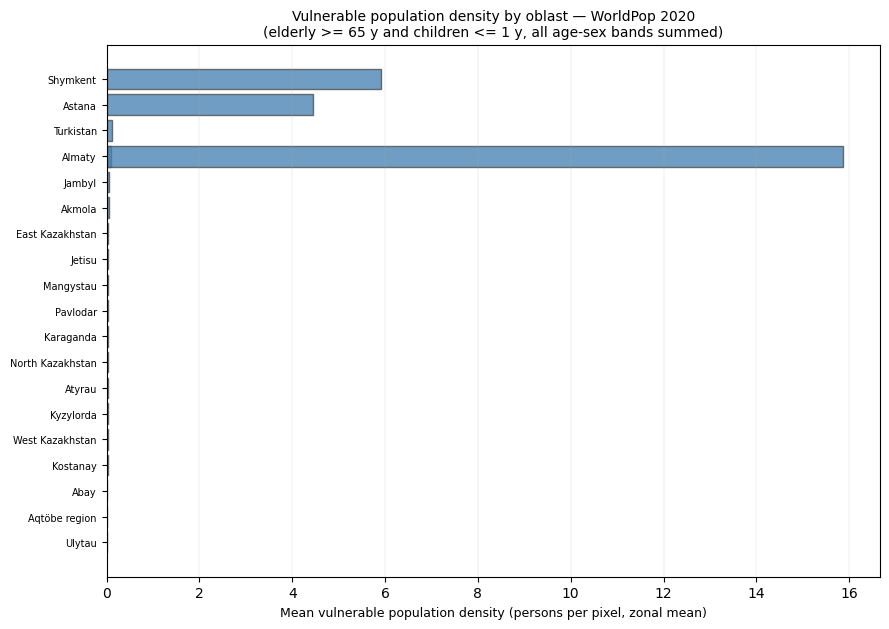

Saved -> Report_figures\fig07_population_density.png


In [10]:
g_vul = gdf_pop.dropna(subset=['pop_mean']).sort_values('pop_mean', ascending=True)
_vlabels = g_vul[OBLAST_FIELD].str.replace(' Region', '', regex=False)

fig, ax = plt.subplots(figsize=(9, max(5, len(g_vul) * 0.32)))
ax.barh(_vlabels, g_vul['pop_mean'],
        color='steelblue', alpha=0.78, edgecolor='0.3')
ax.set_xlabel('Mean vulnerable population density (persons per pixel, zonal mean)', fontsize=9)
ax.set_title(
    'Vulnerable population density by oblast — WorldPop 2020\n'
    '(elderly >= 65 y and children <= 1 y, all age-sex bands summed)',
    fontsize=10,
)
ax.tick_params(axis='y', labelsize=7)
ax.grid(axis='x', linewidth=0.3, alpha=0.5)
plt.tight_layout()
out = REPORT_DIR / 'fig07_population_density.png'
plt.savefig(out, **FIG_KW);  plt.show()
print(f'Saved -> {out}')

## Risk Score Matrix — Oblasts Across Scenarios

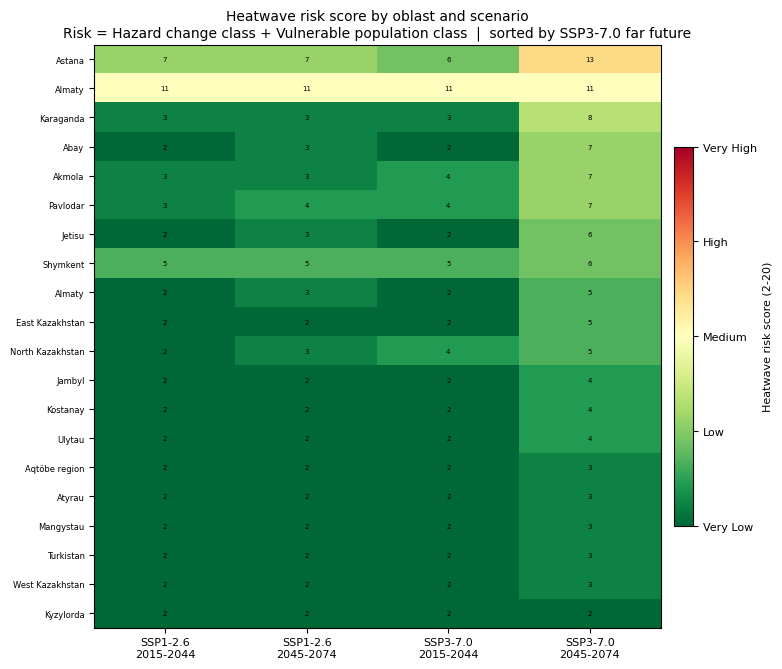

Saved -> Report_figures\fig08_risk_matrix.png


In [ ]:
oblasts_sorted = sorted(gdf_oblasts[OBLAST_FIELD].dropna().unique())
col_labels     = [f'{sc}\n{per}' for sc, _, per in PANELS]

mat = np.full((len(oblasts_sorted), 4), np.nan)
for j, (sc, _, per) in enumerate(PANELS):
    g = risk_gdfs[(sc, per)].set_index(OBLAST_FIELD)
    for i, obl in enumerate(oblasts_sorted):
        if obl in g.index:
            mat[i, j] = float(g.loc[obl, 'risk'])

sort_idx  = np.lexsort((oblasts_sorted, -np.nan_to_num(mat[:, 3], nan=0)))
mat       = mat[sort_idx]
row_labs  = [oblasts_sorted[i].replace(' Region', '') for i in sort_idx]

fig, ax = plt.subplots(figsize=(8, max(6, len(row_labs) * 0.34)))
im = ax.imshow(mat, aspect='auto', cmap='RdYlGn_r', vmin=2, vmax=20)
ax.set_xticks(range(4));  ax.set_xticklabels(col_labels, fontsize=8)
ax.set_yticks(range(len(row_labs)));  ax.set_yticklabels(row_labs, fontsize=6)
cb = plt.colorbar(im, ax=ax, ticks=[2, 6.5, 11, 15.5, 20], shrink=0.65, pad=0.02)
cb.ax.set_yticklabels(['Very Low', 'Low', 'Medium', 'High', 'Very High'], fontsize=8)
cb.set_label('Heatwave risk score (2-20)', fontsize=8)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        if not np.isnan(mat[i, j]):
            ax.text(j, i, f'{mat[i, j]:.0f}',
                    ha='center', va='center', fontsize=5, color='black')
ax.set_title(
    'Heatwave risk score by oblast and scenario\n'
    'Risk = Hazard change class + Vulnerable population class  |  sorted by SSP3-7.0 far future',
    fontsize=10,
)
plt.tight_layout()
out = REPORT_DIR / 'fig08_risk_matrix.png'
plt.savefig(out, **FIG_KW);  plt.show()
print(f'Saved -> {out}')

## Summary Infographic Panel

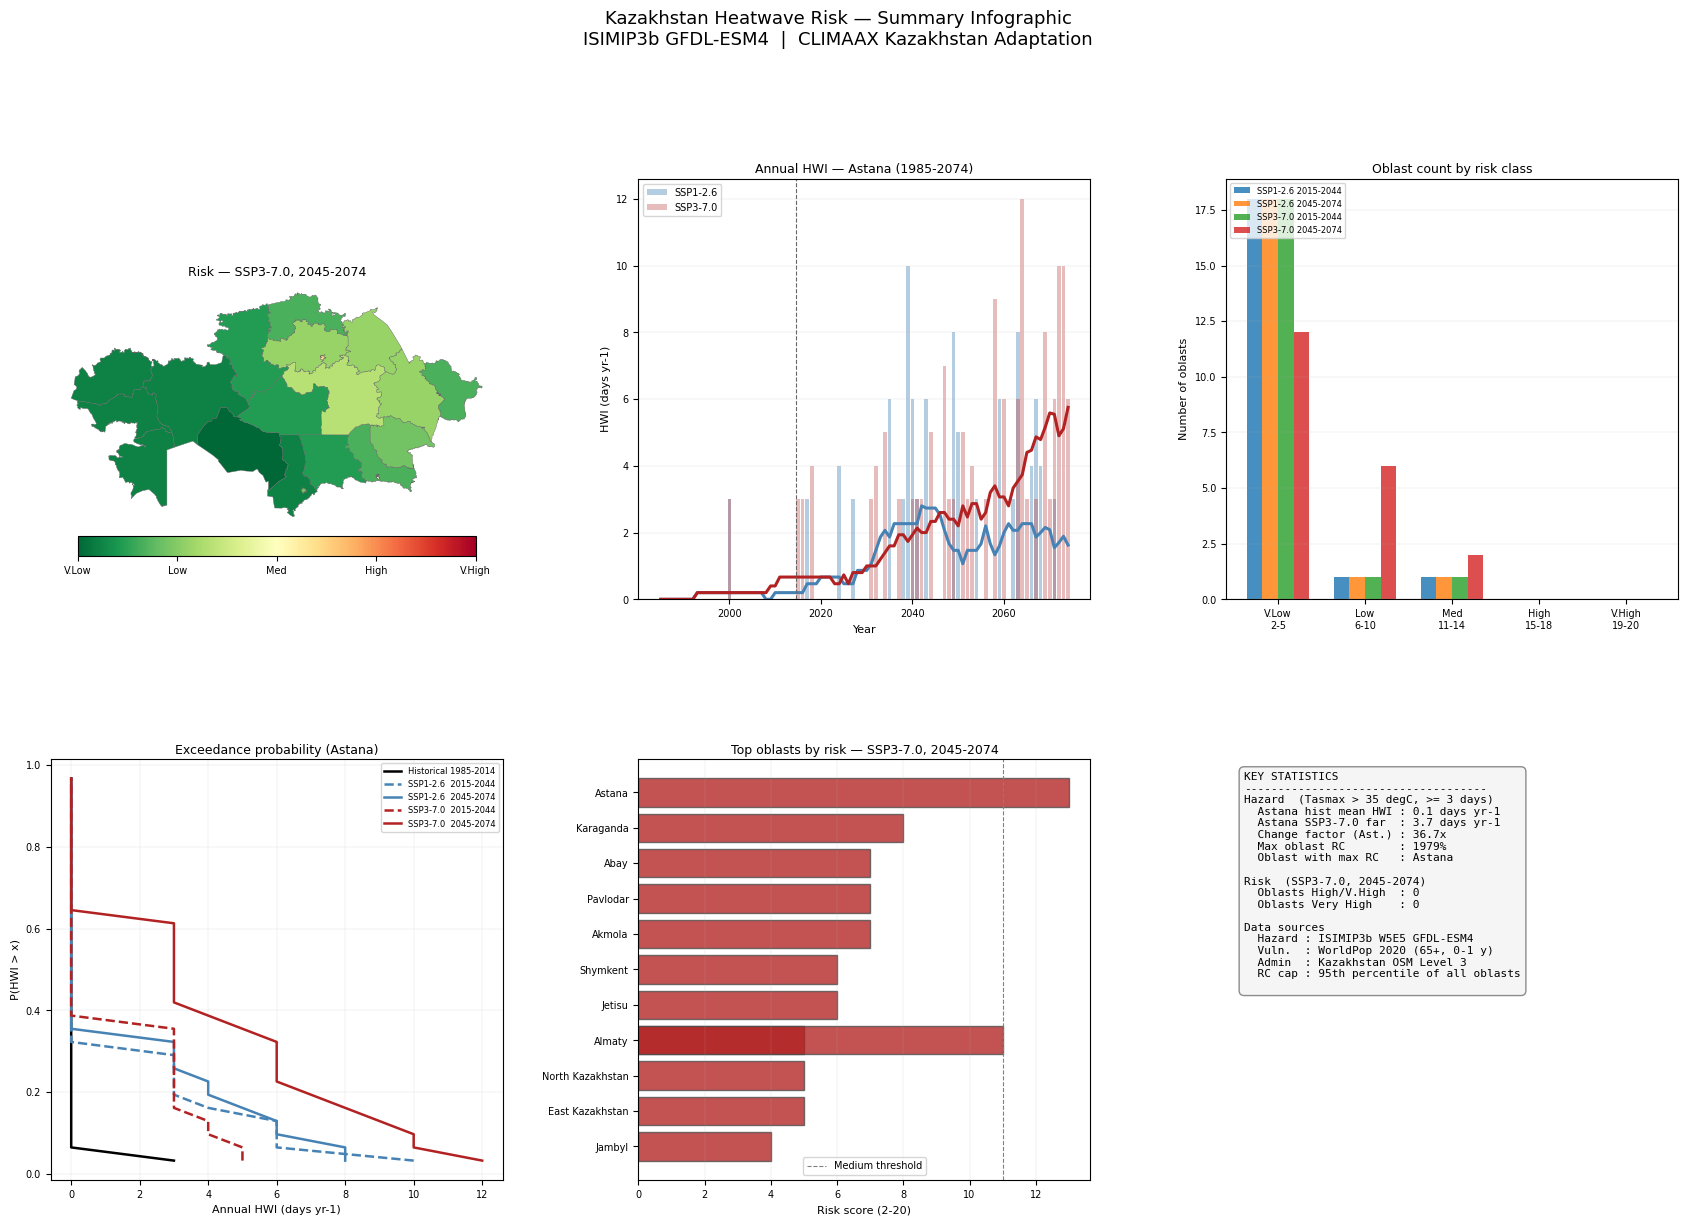

Saved -> Report_figures\fig09_summary_infographic.png

All figures written to C:\Users\dauzo\Models\crabook-kazakhstan\crabook\notebooks\workflows\HEATWAVES\01_Urban_heatwaves\Report_figures


In [ ]:
g_370far = risk_gdfs[('SSP3-7.0', '2045-2074')]
g_rc_far = rc_gdfs[('SSP3-7.0', '2045-2074')]
_yr_mask = np.array([(y >= 1985 and y <= 2074) for y in yrs_full])
_yr_w    = np.array(yrs_full)[_yr_mask]
_t126_w  = ts_full_126[_yr_mask]
_t370_w  = ts_full_370[_yr_mask]

def _roll15(arr):
    return pd.Series(arr).rolling(15, center=True, min_periods=5).mean().values

fig = plt.figure(figsize=(21, 13))
gs  = fig.add_gridspec(2, 3, hspace=0.38, wspace=0.30)

ax00 = fig.add_subplot(gs[0, 0])
g_370far.plot(
    column='risk', ax=ax00, cmap='RdYlGn_r', vmin=2, vmax=20,
    edgecolor='0.4', linewidth=0.3, legend=False,
    missing_kwds={'color': 'lightgrey'},
)
sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=mcolors.Normalize(2, 20))
cb = plt.colorbar(sm, ax=ax00, ticks=[2, 6.5, 11, 15.5, 20],
                  orientation='horizontal', shrink=0.88, pad=0.02)
cb.ax.set_xticklabels(['V.Low', 'Low', 'Med', 'High', 'V.High'], fontsize=7)
ax00.axis('off')
ax00.set_title('Risk — SSP3-7.0, 2045-2074', fontsize=9, pad=4)

ax01 = fig.add_subplot(gs[0, 1])
ax01.bar(_yr_w, _t126_w, color='steelblue', alpha=0.40, width=0.8, label='SSP1-2.6')
ax01.bar(_yr_w, _t370_w, color='firebrick', alpha=0.30, width=0.8, label='SSP3-7.0')
ax01.plot(_yr_w, _roll15(_t126_w), color='steelblue', lw=2.2)
ax01.plot(_yr_w, _roll15(_t370_w), color='firebrick', lw=2.2)
ax01.axvline(2014.5, color='0.4', lw=0.8, ls='--')
ax01.set_xlabel('Year', fontsize=8);  ax01.set_ylabel('HWI (days yr-1)', fontsize=8)
ax01.set_title('Annual HWI — Astana (1985-2074)', fontsize=9, pad=4)
ax01.legend(fontsize=7, loc='upper left');  ax01.tick_params(labelsize=7)
ax01.grid(axis='y', linewidth=0.3, alpha=0.4)

ax02 = fig.add_subplot(gs[0, 2])
_bins     = [(2, 5), (6, 10), (11, 14), (15, 18), (19, 20)]
_blabels  = ['V.Low\n2-5', 'Low\n6-10', 'Med\n11-14', 'High\n15-18', 'V.High\n19-20']
_bcolors  = ['#2c7bb6', '#abd9e9', '#ffffbf', '#fdae61', '#d7191c']
_x        = np.arange(len(_bins))
_w        = 0.18
for k, (sc, _, per) in enumerate(PANELS):
    g  = risk_gdfs[(sc, per)]
    ct = [int(((g['risk'] >= lo) & (g['risk'] <= hi)).sum()) for lo, hi in _bins]
    ax02.bar(_x + (k-1.5)*_w, ct, _w, label=f'{sc} {per}', alpha=0.82)
ax02.set_xticks(_x);  ax02.set_xticklabels(_blabels, fontsize=7)
ax02.set_ylabel('Number of oblasts', fontsize=8)
ax02.set_title('Oblast count by risk class', fontsize=9, pad=4)
ax02.legend(fontsize=6, loc='upper left');  ax02.tick_params(labelsize=7)
ax02.grid(axis='y', linewidth=0.3, alpha=0.4)

ax10 = fig.add_subplot(gs[1, 0])
for label, arr, col, ls in _surv_series:
    v, p = _surv(arr)
    ax10.plot(v, p, color=col, ls=ls, lw=1.8, label=label)
ax10.set_xlabel('Annual HWI (days yr-1)', fontsize=8)
ax10.set_ylabel('P(HWI > x)', fontsize=8)
ax10.set_title('Exceedance probability (Astana)', fontsize=9, pad=4)
ax10.legend(fontsize=6);  ax10.tick_params(labelsize=7)
ax10.grid(linewidth=0.3, alpha=0.4)

ax11 = fig.add_subplot(gs[1, 1])
_top = (g_370far.dropna(subset=['risk'])
        .sort_values('risk', ascending=False)
        .head(12))
_top_labs = _top[OBLAST_FIELD].str.replace(' Region', '', regex=False).values[::-1]
ax11.barh(_top_labs, _top['risk'].values[::-1],
          color='firebrick', alpha=0.78, edgecolor='0.3')
ax11.axvline(11, color='0.5', lw=0.8, ls='--', label='Medium threshold')
ax11.set_xlabel('Risk score (2-20)', fontsize=8)
ax11.set_title('Top oblasts by risk — SSP3-7.0, 2045-2074', fontsize=9, pad=4)
ax11.legend(fontsize=7);  ax11.tick_params(labelsize=7)
ax11.grid(axis='x', linewidth=0.3, alpha=0.4)

ax12 = fig.add_subplot(gs[1, 2])
ax12.axis('off')

_hw_hist_ast = float(hw_hist.sel(lat=ASTANA_LAT, lon=ASTANA_LON, method='nearest'))
_hw_far_ast  = float(hw_370_far.sel(lat=ASTANA_LAT, lon=ASTANA_LON, method='nearest'))
_n_high      = int((g_370far['risk'] >= 15).sum())
_n_vhigh     = int((g_370far['risk'] >= 19).sum())
_rc_far_vals = g_rc_far['rc_mean'].dropna()
_max_rc_val  = float(_rc_far_vals.max())
_max_rc_obl  = g_rc_far.loc[_rc_far_vals.idxmax(), OBLAST_FIELD]

_stats = (
    'KEY STATISTICS\n'
    + '-'*36 + '\n'
    + 'Hazard  (Tasmax > 35 degC, >= 3 days)\n'
    + f'  Astana hist mean HWI : {_hw_hist_ast:.1f} days yr-1\n'
    + f'  Astana SSP3-7.0 far  : {_hw_far_ast:.1f} days yr-1\n'
    + f'  Change factor (Ast.) : {_hw_far_ast/_hw_hist_ast:.1f}x\n'
    + f'  Max oblast RC        : {_max_rc_val:.0f}%\n'
    + f'  Oblast with max RC   : {_max_rc_obl}\n\n'
    + 'Risk  (SSP3-7.0, 2045-2074)\n'
    + f'  Oblasts High/V.High  : {_n_high}\n'
    + f'  Oblasts Very High    : {_n_vhigh}\n\n'
    + 'Data sources\n'
    + f'  Hazard : ISIMIP3b W5E5 {MODEL.upper()}\n'
    + '  Vuln.  : WorldPop 2020 (65+, 0-1 y)\n'
    + '  Admin  : Kazakhstan OSM Level 3\n'
    + '  RC cap : 95th percentile of all oblasts\n'
)
ax12.text(0.04, 0.97, _stats, transform=ax12.transAxes,
          fontsize=8, family='monospace', va='top',
          bbox={'boxstyle': 'round,pad=0.45',
                'facecolor': 'whitesmoke', 'edgecolor': '0.55'})

plt.suptitle(
    f'Kazakhstan Heatwave Risk — Summary Infographic\n'
    f'ISIMIP3b {MODEL.upper()}  |  CLIMAAX Kazakhstan Adaptation',
    fontsize=13, y=1.01,
)
out = REPORT_DIR / 'fig09_summary_infographic.png'
plt.savefig(out, **FIG_KW);  plt.show()
print(f'Saved -> {out}')

print(f'\nAll figures written to {REPORT_DIR.resolve()}')